# 导入库

In [840]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import seaborn as sns
import warnings
from functools import reduce
from scipy.stats import chi2_contingency
import pywt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import export_graphviz
import graphviz
plt.rcParams['font.sans-serif'] = ['SimHei']  # 正常显示中文
plt.rcParams['axes.unicode_minus']=False      # 用来正常显示负号
warnings.filterwarnings('ignore')

# 数据读入与整合

## 下载的数据导入

In [875]:
#创建一个数组存dataset名字
dataset_name = []
# 创建一个字典存dataset
dataset_dict = {}
# 创建一个数组存
for i in range(2016,2024):
#   2020年温网取消了
    if i != 2020:
        key = str(i)+'-wimbledon-points'
        value = pd.read_csv('./wimbledon-points2011-2023/'+key+'.csv')
        dataset_dict[key] = value

In [876]:
# 去掉空白的列
for key, df in dataset_dict.items():
    dataset_dict[key] = df.dropna(axis=1, how='all')
print(dataset_dict['2023-wimbledon-points'].columns.values)

['match_id' 'ElapsedTime' 'SetNo' 'P1GamesWon' 'P2GamesWon' 'SetWinner'
 'GameNo' 'GameWinner' 'PointNumber' 'PointWinner' 'PointServer'
 'Speed_KMH' 'P1Score' 'P2Score' 'P1Momentum' 'P2Momentum' 'P1PointsWon'
 'P2PointsWon' 'P1Ace' 'P2Ace' 'P1Winner' 'P2Winner' 'P1DoubleFault'
 'P2DoubleFault' 'P1UnfErr' 'P2UnfErr' 'P1NetPoint' 'P2NetPoint'
 'P1NetPointWon' 'P2NetPointWon' 'P1BreakPoint' 'P2BreakPoint'
 'P1BreakPointWon' 'P2BreakPointWon' 'History' 'Speed_MPH'
 'P1BreakPointMissed' 'P2BreakPointMissed' 'ServeIndicator' 'ServeNumber'
 'WinnerType' 'WinnerShotType' 'P1DistanceRun' 'P2DistanceRun'
 'RallyCount' 'ServeWidth' 'ServeDepth' 'ReturnDepth']


In [877]:
# 找出12个df共同的列
columns_sets = [set(df.columns) for df in dataset_dict.values()]
columns_inter = reduce(set.intersection, columns_sets)
# 打印结果
print("列名交集:", columns_inter)
print("数量:",len(columns_inter))
# 只保留相同的列
for key, df in dataset_dict.items():
    dataset_dict[key] = df.loc[:, columns_inter]
dataset_dict['2023-wimbledon-points'].head()

列名交集: {'P1Score', 'P1Winner', 'P2GamesWon', 'RallyCount', 'GameWinner', 'P2BreakPointMissed', 'ServeIndicator', 'ServeNumber', 'SetNo', 'ElapsedTime', 'ServeDepth', 'P2Winner', 'ReturnDepth', 'P1NetPointWon', 'P2BreakPoint', 'P1PointsWon', 'P2NetPoint', 'P1DistanceRun', 'WinnerShotType', 'P1BreakPointMissed', 'SetWinner', 'P1Ace', 'PointWinner', 'PointServer', 'P2NetPointWon', 'P2Score', 'P1GamesWon', 'ServeWidth', 'P1DoubleFault', 'P2UnfErr', 'P1BreakPoint', 'match_id', 'P1UnfErr', 'P2BreakPointWon', 'GameNo', 'P2DistanceRun', 'WinnerType', 'Speed_MPH', 'History', 'P1NetPoint', 'Speed_KMH', 'P2PointsWon', 'PointNumber', 'P2Ace', 'P2DoubleFault', 'P1BreakPointWon'}
数量: 46


,P1Score,P1Winner,P2GamesWon,RallyCount,GameWinner,P2BreakPointMissed,ServeIndicator,ServeNumber,SetNo,ElapsedTime,...,WinnerType,Speed_MPH,History,P1NetPoint,Speed_KMH,P2PointsWon,PointNumber,P2Ace,P2DoubleFault,P1BreakPointWon
0,0,0,0,0,0,0,0,0,1,0:00:00,...,0,0,NaN,0,0,0,0X,0,0,0
1,0,0,0,0,0,0,0,0,1,0:00:00,...,0,0,NaN,0,0,0,0Y,0,0,0
2,0,0,0,1,0,0,2,1,1,0:00:00,...,0,117,12030.0,0,188,1,1,0,0,0
3,15,1,0,4,0,0,2,1,1,0:00:20,...,0,124,11010.0,0,199,1,2,0,0,0
4,30,0,0,0,0,0,2,0,1,0:00:51,...,0,0,25000.0,0,0,1,3,0,1,0


## 题目数据导入

In [1087]:
problem_data = pd.read_csv('./wimbledon-points2011-2023/Wimbledon_featured_matches.csv')
print(len(problem_data.columns))
problem_data.head()
print(problem_data.columns)

44
Index(['match_id', 'elapsed_time', 'set_no', 'game_no', 'point_no', 'p1_sets',
       'p2_sets', 'p1_games', 'p2_games', 'p1_score', 'p2_score', 'server',
       'serve_no', 'point_victor', 'p1_points_won', 'p2_points_won',
       'game_victor', 'set_victor', 'p1_ace', 'p2_ace', 'p1_winner',
       'p2_winner', 'winner_shot_type', 'p1_double_fault', 'p2_double_fault',
       'p1_unf_err', 'p2_unf_err', 'p1_net_pt', 'p2_net_pt', 'p1_net_pt_won',
       'p2_net_pt_won', 'p1_break_pt', 'p2_break_pt', 'p1_break_pt_won',
       'p2_break_pt_won', 'p1_break_pt_missed', 'p2_break_pt_missed',
       'p1_distance_run', 'p2_distance_run', 'rally_count', 'speed_mph',
       'serve_width', 'serve_depth', 'return_depth'],
      dtype='object')


In [1077]:
drop_columns = ['Speed_KMH', 'History', 'WinnerType', 'ServeIndicator']
print(dataset_dict['2023-wimbledon-points'].columns)
print(len(dataset_dict['2023-wimbledon-points'].columns))

Index(['match_id', 'elapsed_time', 'champion', 'set_no', 'game_no', 'point_no',
       'p1_games', 'p2_games', 'p1_score', 'p2_score', 'server', 'serve_no',
       'point_victor', 'p1_points_won', 'p2_points_won', 'game_victor',
       'set_victor', 'p1_sets', 'p2_sets', 'p1_ace', 'p2_ace', 'p1_winner',
       'p2_winner', 'winner_shot_type', 'p1_double_fault', 'p2_double_fault',
       'p1_unf_err', 'p2_unf_err', 'p1_net_pt', 'p2_net_pt', 'p1_net_pt_won',
       'p2_net_pt_won', 'p1_break_pt', 'p2_break_pt', 'p1_break_pt_won',
       'p2_break_pt_won', 'p1_break_pt_missed', 'p2_break_pt_missed',
       'p1_distance_run', 'p2_distance_run', 'rally_count', 'speed_mph',
       'serve_width', 'serve_depth', 'return_depth'],
      dtype='object')
45


In [880]:
new_columns = ['p1_score', 'p1_winner', 'p2_games', 'rally_count', 'game_victor',
               'p2_break_pt_missed', 'serve_no', 'set_no',
               'elapsed_time', 'serve_depth', 'p2_winner', 'return_depth', 'p1_net_pt_won',
               'p2_break_pt', 'p1_points_won', 'p2_net_pt', 'p1_distance_run',
               'winner_shot_type', 'p1_break_pt_missed', 'set_victor', 'p1_ace',
               'point_victor', 'server', 'p2_net_pt_won', 'p2_score', 'p1_games',
               'serve_width', 'p1_double_fault', 'p2_unf_err', 'p1_break_pt', 'match_id',
               'p1_unf_err', 'p2_break_pt_won', 'game_no', 'p2_distance_run',
               'Speed_MPH',  'p1_net_pt', 'p2_points_won',
               'point_no', 'p2_ace', 'p2_double_fault', 'p1_break_pt_won']
for key, df in dataset_dict.items():
    dataset_dict[key] = df.drop(columns=drop_columns)
    dataset_dict[key].columns = new_columns

In [881]:
dataset_dict['2023-wimbledon-points'].head()

,p1_score,p1_winner,p2_games,rally_count,game_victor,p2_break_pt_missed,serve_no,set_no,elapsed_time,serve_depth,...,p2_break_pt_won,game_no,p2_distance_run,Speed_MPH,p1_net_pt,p2_points_won,point_no,p2_ace,p2_double_fault,p1_break_pt_won
0,0,0,0,0,0,0,0,1,0:00:00,NaN,...,0,1,0.000,0,0,0,0X,0,0,0
1,0,0,0,0,0,0,0,1,0:00:00,NaN,...,0,1,0.000,0,0,0,0Y,0,0,0
2,0,0,0,1,0,0,1,1,0:00:00,NCTL,...,0,1,5.931,117,0,1,1,0,0,0
3,15,1,0,4,0,0,1,1,0:00:20,NCTL,...,0,1,10.694,124,0,1,2,0,0,0
4,30,0,0,0,0,0,0,1,0:00:51,NCTL,...,0,1,5.828,0,0,1,3,0,1,0


In [882]:
print(dataset_dict['2023-wimbledon-points'].columns)
print(len(dataset_dict['2023-wimbledon-points'].columns))

Index(['p1_score', 'p1_winner', 'p2_games', 'rally_count', 'game_victor',
       'p2_break_pt_missed', 'serve_no', 'set_no', 'elapsed_time',
       'serve_depth', 'p2_winner', 'return_depth', 'p1_net_pt_won',
       'p2_break_pt', 'p1_points_won', 'p2_net_pt', 'p1_distance_run',
       'winner_shot_type', 'p1_break_pt_missed', 'set_victor', 'p1_ace',
       'point_victor', 'server', 'p2_net_pt_won', 'p2_score', 'p1_games',
       'serve_width', 'p1_double_fault', 'p2_unf_err', 'p1_break_pt',
       'match_id', 'p1_unf_err', 'p2_break_pt_won', 'game_no',
       'p2_distance_run', 'Speed_MPH', 'p1_net_pt', 'p2_points_won',
       'point_no', 'p2_ace', 'p2_double_fault', 'p1_break_pt_won'],
      dtype='object')
42


In [883]:
new_columns = ['match_id', 'elapsed_time', 'set_no', 'game_no', 'point_no', 
               'p1_games', 'p2_games', 'p1_score', 'p2_score', 'server',
               'serve_no', 'point_victor', 'p1_points_won', 'p2_points_won',
               'game_victor', 'set_victor', 'p1_ace', 'p2_ace', 'p1_winner',
               'p2_winner', 'winner_shot_type', 'p1_double_fault', 'p2_double_fault',
               'p1_unf_err', 'p2_unf_err', 'p1_net_pt', 'p2_net_pt', 'p1_net_pt_won',
               'p2_net_pt_won', 'p1_break_pt', 'p2_break_pt', 'p1_break_pt_won',
               'p2_break_pt_won', 'p1_break_pt_missed', 'p2_break_pt_missed',
               'p1_distance_run', 'p2_distance_run', 'rally_count', 'speed_mph',
               'serve_width', 'serve_depth', 'return_depth']
for key, df in dataset_dict.items():
    dataset_dict[key] = df.reindex(columns=new_columns)

In [884]:
dataset_dict['2023-wimbledon-points'].head()

,match_id,elapsed_time,set_no,game_no,point_no,p1_games,p2_games,p1_score,p2_score,server,...,p2_break_pt_won,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth
0,2023-wimbledon-1101,0:00:00,1,1,0X,0,0,0,0,0,...,0,0,0,0.000,0.000,0,NaN,NaN,NaN,NaN
1,2023-wimbledon-1101,0:00:00,1,1,0Y,0,0,0,0,0,...,0,0,0,0.000,0.000,0,NaN,NaN,NaN,NaN
2,2023-wimbledon-1101,0:00:00,1,1,1,0,0,0,15,2,...,0,0,0,7.486,5.931,1,NaN,BC,NCTL,D
3,2023-wimbledon-1101,0:00:20,1,1,2,0,0,15,15,2,...,0,0,0,9.093,10.694,4,NaN,BC,NCTL,ND
4,2023-wimbledon-1101,0:00:51,1,1,3,0,0,30,15,2,...,0,0,0,9.013,5.828,0,NaN,C,NCTL,ND


## 删掉多余的行，将下载的数据和问题的数据统一格式

In [885]:
for key, df in dataset_dict.items():
    dataset_dict[key] = df[~((df['point_no'] == '0X') | (df['point_no'] == '0Y'))]
dataset_dict['2023-wimbledon-points'].head()

,match_id,elapsed_time,set_no,game_no,point_no,p1_games,p2_games,p1_score,p2_score,server,...,p2_break_pt_won,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth
2,2023-wimbledon-1101,0:00:00,1,1,1,0,0,0,15,2,...,0,0,0,7.486,5.931,1,NaN,BC,NCTL,D
3,2023-wimbledon-1101,0:00:20,1,1,2,0,0,15,15,2,...,0,0,0,9.093,10.694,4,NaN,BC,NCTL,ND
4,2023-wimbledon-1101,0:00:51,1,1,3,0,0,30,15,2,...,0,0,0,9.013,5.828,0,NaN,C,NCTL,ND
5,2023-wimbledon-1101,0:01:21,1,1,4,0,0,40,15,2,...,0,0,0,3.617,2.871,0,NaN,W,CTL,NaN
6,2023-wimbledon-1101,0:01:49,1,1,5,0,0,40,30,2,...,0,1,0,34.272,27.526,7,NaN,W,CTL,D


In [886]:
# 把某些行下移
for key, df in dataset_dict.items():
    dataset_dict[key]['p1_games'] = df['p1_games'].shift(1, fill_value=0)
    dataset_dict[key]['p2_games'] = df['p2_games'].shift(1, fill_value=0)
    dataset_dict[key]['p1_score'] = df['p1_score'].shift(1, fill_value=0)
    dataset_dict[key]['p2_score'] = df['p2_score'].shift(1, fill_value=0)

In [887]:
dataset_dict['2023-wimbledon-points'].head()

,match_id,elapsed_time,set_no,game_no,point_no,p1_games,p2_games,p1_score,p2_score,server,...,p2_break_pt_won,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth
2,2023-wimbledon-1101,0:00:00,1,1,1,0,0,0,0,2,...,0,0,0,7.486,5.931,1,NaN,BC,NCTL,D
3,2023-wimbledon-1101,0:00:20,1,1,2,0,0,0,15,2,...,0,0,0,9.093,10.694,4,NaN,BC,NCTL,ND
4,2023-wimbledon-1101,0:00:51,1,1,3,0,0,15,15,2,...,0,0,0,9.013,5.828,0,NaN,C,NCTL,ND
5,2023-wimbledon-1101,0:01:21,1,1,4,0,0,30,15,2,...,0,0,0,3.617,2.871,0,NaN,W,CTL,NaN
6,2023-wimbledon-1101,0:01:49,1,1,5,0,0,40,15,2,...,0,1,0,34.272,27.526,7,NaN,W,CTL,D


## 填充缺失值

In [1088]:
problem_data.isnull().sum()

match_id                 0
elapsed_time             0
set_no                   0
game_no                  0
point_no                 0
p1_sets                  0
p2_sets                  0
p1_games                 0
p2_games                 0
p1_score                 0
p2_score                 0
server                   0
serve_no                 0
point_victor             0
p1_points_won            0
p2_points_won            0
game_victor              0
set_victor               0
p1_ace                   0
p2_ace                   0
p1_winner                0
p2_winner                0
winner_shot_type         0
p1_double_fault          0
p2_double_fault          0
p1_unf_err               0
p2_unf_err               0
p1_net_pt                0
p2_net_pt                0
p1_net_pt_won            0
p2_net_pt_won            0
p1_break_pt              0
p2_break_pt              0
p1_break_pt_won          0
p2_break_pt_won          0
p1_break_pt_missed       0
p2_break_pt_missed       0
p

In [1089]:
mean = problem_data[problem_data['speed_mph'] != 0]['speed_mph'].mean()
problem_data['speed_mph'].fillna(mean, inplace=True)
mode = problem_data['serve_width'].mode().iloc[0]
problem_data['serve_width'].fillna(mode, inplace=True)
mode = problem_data['serve_depth'].mode().iloc[0]
problem_data['serve_depth'].fillna(mode, inplace=True)
mode = problem_data['return_depth'].mode().iloc[0]
print(mode)
problem_data['return_depth'].fillna(mode, inplace=True)
problem_data['p1_score'].replace('AD', 50, inplace=True)
problem_data['p2_score'].replace('AD', 50, inplace=True)
problem_data.isnull().sum()

ND


match_id              0
elapsed_time          0
set_no                0
game_no               0
point_no              0
p1_sets               0
p2_sets               0
p1_games              0
p2_games              0
p1_score              0
p2_score              0
server                0
serve_no              0
point_victor          0
p1_points_won         0
p2_points_won         0
game_victor           0
set_victor            0
p1_ace                0
p2_ace                0
p1_winner             0
p2_winner             0
winner_shot_type      0
p1_double_fault       0
p2_double_fault       0
p1_unf_err            0
p2_unf_err            0
p1_net_pt             0
p2_net_pt             0
p1_net_pt_won         0
p2_net_pt_won         0
p1_break_pt           0
p2_break_pt           0
p1_break_pt_won       0
p2_break_pt_won       0
p1_break_pt_missed    0
p2_break_pt_missed    0
p1_distance_run       0
p2_distance_run       0
rally_count           0
speed_mph             0
serve_width     

In [890]:
for key, df in dataset_dict.items():
    df['speed_mph'] = pd.to_numeric(df['speed_mph'], errors='coerce')
    mean = df[df['speed_mph'] != 0]['speed_mph'].mean()
    dataset_dict[key]['speed_mph'].fillna(mean, inplace=True)
    mode = df['serve_width'].mode().iloc[0]
    dataset_dict[key]['serve_width'].fillna(mode, inplace=True)
    mode = df['serve_depth'].mode().iloc[0]
    dataset_dict[key]['serve_depth'].fillna(mode, inplace=True)
    mode = df['return_depth'].mode().iloc[0]
    dataset_dict[key]['return_depth'].fillna(mode, inplace=True)
    dataset_dict[key]['p1_score'].replace('AD', 50, inplace=True)
    dataset_dict[key]['p2_score'].replace('AD', 50, inplace=True)

## 处理异常值

In [1090]:
# 改正server列的异常值
# server = 1 or 2
server = problem_data['server'][0]
for i in range(1,len(problem_data)):
    problem_data['server'][i] = server
    if(problem_data['game_victor'][i] != 0) and i != (len(problem_data) - 1):
        server = problem_data['server'][i+1]

In [ ]:
# 改正server列的异常值
# for key, df in dataset_dict.items():
#     server = df['server'][0]
#     for i in range(1,len(df)):
#         df['server'][i] = server
#         if(df['game_victor'][i] != 0) and i != (len(df) - 1):
#             server = df['server'][i+1]
#     dataset_dict[key] = df

## 下载的数据集中set比分计算

In [1093]:
problem_data.insert(2, 'champion', 0)
set1 = set2 = 0
for index, victor in enumerate(problem_data['set_victor'].values):
    problem_data['p1_sets'][index] = set1
    problem_data['p2_sets'][index] = set2
    if victor == 1:
        set1 += 1
        if set1 == 3:
            set1 = set2 = 0
            problem_data['champion'][index] = 1
    elif victor == 2:
        set2 += 1
        if set2 == 3:
            set1 = set2 = 0
            problem_data['champion'][index] = 2

In [892]:
for key, df in dataset_dict.items():
    dataset_dict[key].insert(df.columns.get_loc('set_victor') + 1, 'p1_sets', 0)
    dataset_dict[key].insert(df.columns.get_loc('set_victor') + 2, 'p2_sets', 0)
    dataset_dict[key].insert(2, 'champion', 0)
    set1 = set2 = 0
    for index, victor in enumerate(dataset_dict[key]['set_victor'].values):
        dataset_dict[key]['p1_sets'][index] = set1
        dataset_dict[key]['p2_sets'][index] = set2
        if victor == 1:
            set1 += 1
            if set1 == 3:
                set1 = set2 = 0
                dataset_dict[key]['champion'][index] = 1
        elif victor == 2:
            set2 += 1
            if set2 == 3:
                set1 = set2 = 0
                dataset_dict[key]['champion'][index] = 2

## 重新导出数据

In [1094]:
problem_data.to_csv('Wimbledon_featured_matches.csv', index=False)

In [894]:
for key, df in dataset_dict.items():
    file_name = key + '.csv'
    df.to_csv(file_name, index=False)

## Momentum的因子：factor计算

In [970]:
# 23年温网男单决赛
# data = problem_data[problem_data['match_id'] == '2023-wimbledon-1701'].reset_index(drop=True)
# 21年温网男单第一场
# data = dataset_dict['2021-wimbledon-points']
# data = data[data['match_id'] == '2021-wimbledon-1101'].reset_index(drop=True)
# 21年温网男单第三场
# data = dataset_dict['2021-wimbledon-points']
# data = data[data['match_id'] == '2021-wimbledon-1103'].reset_index(drop=True)
# 19年温网男单第一场
# data = dataset_dict['2019-wimbledon-points']
# data = data[data['match_id'] == '2019-wimbledon-1101'].reset_index(drop=True)
# 18年温网男单第五场
data = dataset_dict['2018-wimbledon-points']
data = data[data['match_id'] == '2018-wimbledon-1105'].reset_index(drop=True)
def Factor(data):
    p1_factor = []
    p2_factor = []
    for index, row in data.iterrows():
        p1 = p2 = 0
    #   发球方
        if row['server'] == 1:
            p1 += 3
    #   set得分差距
        set_diff = abs(row['p1_sets'] - row['p2_sets']) 
        if set_diff == 1:
            if row['p1_sets'] > row['p2_sets']:
                p1 += 2
                p2 -= 2
            else:
                p1 -= 2
                p2 += 2
        elif set_diff == 2:
            if row['p1_sets'] > row['p2_sets']:
                p1 += 5
                p2 -= 5
            else:
                p1 -= 5
                p2 += 5
    #    连续得分
        if index >= 2:
            if data['point_victor'][index] == 1 and data['point_victor'][index-1] == 1 and data['point_victor'][index-2] == 1:
                p1 += 2
                p2 -= 2
            elif data['point_victor'][index] == 2 and data['point_victor'][index-1] == 2 and data['point_victor'][index-2] == 2:
                p1 -= 2
                p2 += 2
    #    破发赛点
        if row['p1_break_pt'] == 1:
            p1 += 5
            p2 -= 5
            if row['p1_break_pt_won'] == 1:
                p1 += 8
                p2 -= 8
        if row['p2_break_pt'] == 1:
            p1 -= 5
            p2 += 5
            if row['p2_break_pt_won'] == 1:
                p1 -= 8
                p2 += 8
    #    双误
        if row['p1_double_fault'] == 1:
            p1 -= 3
        if row['p2_double_fault'] == 1:
            p2 -= 3
    #    非受迫性失分
        if row['p1_unf_err'] == 1:
            p1 -= 1
        if row['p2_unf_err'] == 1:
            p2 -= 1
    #    发球秒杀
        if row['p1_ace'] == 1:
            p1 += 4
            p2 -= 4
        if row['p2_ace'] == 1:
            p1 -= 4
            p2 += 4
    #    击球秒杀
        if row['p1_winner'] == 1:
            p1 += 3
            p2 -= 3
        if row['p2_winner'] == 1:
            p1 -= 3
            p2 += 3
    #    该球得分
        if row['point_victor'] == 1:
            p1 += 1
        if row['point_victor'] == 2:
            p2 += 1
    #    添加到两个球员的factor数组中
        p1_factor.append(p1)
        p2_factor.append(p2)
    return p1_factor, p2_factor
p1_factor, p2_factor = Factor(data)

## 两个球员的factor变化图

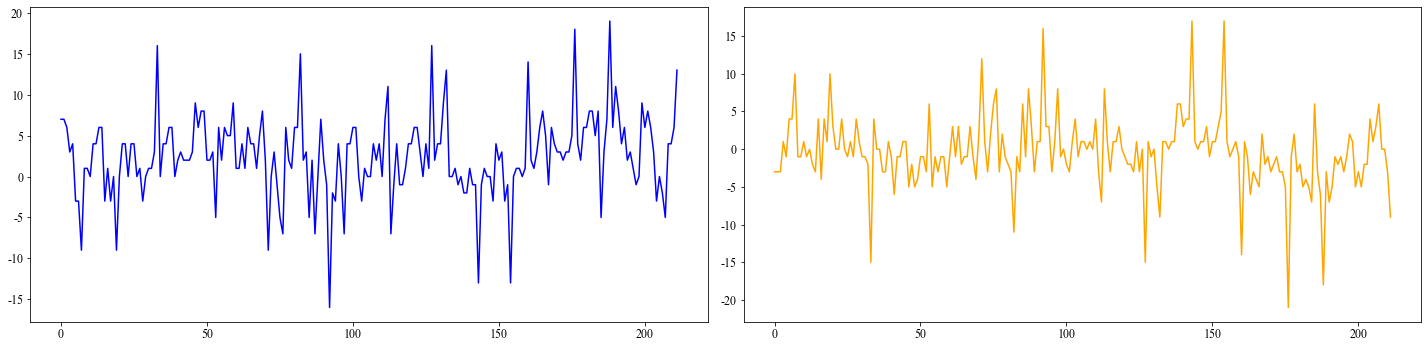

In [971]:
plt.figure(figsize=(20,5))
plt.subplot(1, 2, 1)
plt.plot(p1_factor, linestyle='-', color='b', label='Line')
plt.subplot(1, 2, 2)
plt.plot(p2_factor, linestyle='-', color='orange', label='Line')
plt.tight_layout()
plt.show()

## Momentum计算

In [972]:
def Momentum(p1_factor, p2_factor):
    p1_mmt = []
    p2_mmt = []
    def MMT(factor):
        a = 0.8
        w = 1 - a
        b = 1
        y = factor[0]
        for t, x in enumerate(factor):
            if t != 0:
                y += w*x
                b += w
                w = (1-a)**(t+1)
        return y/b

    for i in range(len(p1_factor)):
        if i < 4:
            p1_mmt.append(MMT(p1_factor[:i+1]))
            p2_mmt.append(MMT(p2_factor[:i+1]))
        else:
            p1_mmt.append(MMT(p1_factor[i-4:i+1]))
            p2_mmt.append(MMT(p2_factor[i-4:i+1]))
    return p1_mmt, p2_mmt
p1_mmt, p2_mmt = Momentum(p1_factor, p2_factor)

## 球员的Momentum变化图

## 找波动点（双发势头接近，意味局势即将变化）

In [973]:
# 定义阈值
b = 0.5
# 转换为 Pandas 的 Series 对象
p1_series = pd.Series(p1_mmt)
p2_series = pd.Series(p2_mmt)
# 计算波动点
momentum_points = (p1_series - p2_series).abs() < b
result = p1_series[momentum_points]
len(result)

13

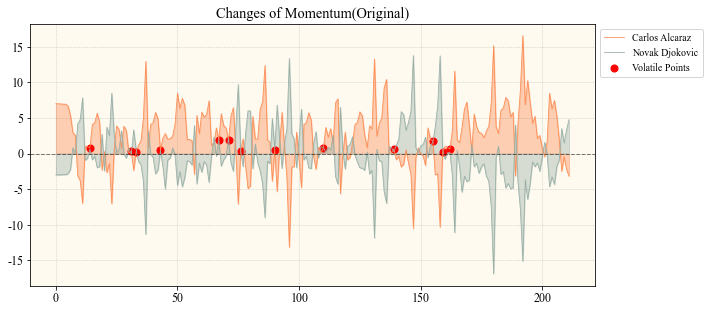

In [974]:
fig, ax = plt.subplots(figsize=(10, 4.5))
plt.grid(ls = "--", lw = 0.5, color = "#4E616C", alpha=0.3)
plt.gca().set_facecolor('#FFFAF0')
plt.plot(p1_mmt, linestyle='-', color='#FC8E56', label='Carlos Alcaraz', lw = 0.8)
plt.plot(p2_mmt, linestyle='-', color='#99B0A7', label='Novak Djokovic', lw = 0.8)
# 在折线图下方填充颜色
ax.fill_between(range(len(p1_mmt)), p1_mmt, color='#FC8E56', interpolate=True, alpha=0.4)
ax.fill_between(range(len(p2_mmt)), p2_mmt, color='#99B0A7', interpolate=True, alpha=0.4)
# 绘制波动点
plt.scatter(result.index, result, color='red', label='Volatile Points', s = 50)
# 添加 y=0 的参考线
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha = 0.5)
plt.legend(bbox_to_anchor=(1.2, 1),prop={'size': 10})
plt.title('Changes of Momentum(Original)')
plt.tight_layout()
# plt.savefig('./波动点标记.png',dpi=500)
plt.show()

In [947]:
# 新加一列数据标注是否是波动点
# 23年温网男单决赛
# data = problem_data[problem_data['match_id'] == '2023-wimbledon-1701'].reset_index(drop=True)
# 21年温网男单第一场
# data = dataset_dict['2021-wimbledon-points']
# data = data[data['match_id'] == '2021-wimbledon-1101'].reset_index(drop=True)
# 21年温网男单第三场
# data = dataset_dict['2021-wimbledon-points']
# data = data[data['match_id'] == '2021-wimbledon-1103'].reset_index(drop=True)
# 19年温网男单第一场
# data = dataset_dict['2019-wimbledon-points']
# data = data[data['match_id'] == '2019-wimbledon-1101'].reset_index(drop=True)
# 18年温网男单第五场
data = dataset_dict['2018-wimbledon-points']
data = data[data['match_id'] == '2018-wimbledon-1105'].reset_index(drop=True)
data['is_volatile_pt'] = 0
data.loc[result.index, 'is_volatile_pt'] = 1

In [948]:
vlt_pt_data = data[['p1_ace', 'p2_ace', 'p1_winner', 'p2_winner',
                             'p1_double_fault', 'p2_double_fault', 'p1_unf_err', 'p2_unf_err',
                             'p1_break_pt', 'p2_break_pt', 'p1_break_pt_won', 'p2_break_pt_won','is_volatile_pt']]

vlt_pt_data['ace'] = (vlt_pt_data['p1_ace'] | vlt_pt_data['p2_ace'])
vlt_pt_data['winner'] = (vlt_pt_data['p1_winner'] | vlt_pt_data['p2_winner'])
vlt_pt_data['double_fault'] = (vlt_pt_data['p1_double_fault'] | vlt_pt_data['p2_double_fault'])
vlt_pt_data['unf_err'] = (vlt_pt_data['p1_unf_err'] | vlt_pt_data['p2_unf_err'])
vlt_pt_data['break_pt'] = (vlt_pt_data['p1_break_pt'] | vlt_pt_data['p2_break_pt'])
vlt_pt_data['break_pt_won'] = (vlt_pt_data['p1_break_pt_won'] | vlt_pt_data['p2_break_pt_won'])

vlt_pt_data.drop(columns=['p1_ace', 'p2_ace', 'p1_winner', 'p2_winner',
                          'p1_double_fault', 'p2_double_fault', 'p1_unf_err', 'p2_unf_err',
                          'p1_break_pt', 'p2_break_pt', 'p1_break_pt_won', 'p2_break_pt_won'], inplace=True)
vlt_pt_data

,is_volatile_pt,ace,winner,double_fault,unf_err,break_pt,break_pt_won
0,0,0,1,0,0,0,0
1,0,0,1,0,0,0,0
2,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...
207,0,0,1,0,0,0,0
208,0,0,0,0,0,0,0
209,0,0,0,0,0,0,0
210,0,0,0,0,1,0,0


In [908]:
# total_vltp_data = pd.DataFrame({'is_volatile_pt':[],'ace':[],'winner':[],'double_fault':[],'unf_err':[],'break_pt':[],'break_pt_won':[]})
total_vltp_data

,is_volatile_pt,ace,winner,double_fault,unf_err,break_pt,break_pt_won


In [949]:
total_vltp_data = pd.concat([total_vltp_data, vlt_pt_data], ignore_index=True)
total_vltp_data

,is_volatile_pt,ace,winner,double_fault,unf_err,break_pt,break_pt_won
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
1199,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1200,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1201,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1202,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [952]:
len(total_vltp_data[total_vltp_data['is_volatile_pt'] == 1])

72

In [1030]:
vltp_data = total_vltp_data[total_vltp_data['is_volatile_pt'] == 1].reset_index(drop=True)
no_vltp_data = total_vltp_data[total_vltp_data['is_volatile_pt'] == 0].reset_index(drop=True)

# 设置抽样次数和每次抽样的样本数量
num_samples = 1
sample_size = 600

# 进行有放回的随机抽样
samples = [vltp_data.sample(sample_size, replace=True) for _ in range(num_samples)]
vltp_sample = pd.concat(samples, ignore_index=True)
samples = [no_vltp_data.sample(sample_size, replace=True) for _ in range(num_samples)]
no_vltp_data = pd.concat(samples, ignore_index=True)
total_vltp_data = pd.concat([vltp_sample, no_vltp_data], ignore_index=True).reset_index(drop=True)
total_vltp_data

,is_volatile_pt,ace,winner,double_fault,unf_err,break_pt,break_pt_won
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
1195,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1196,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1197,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1198,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 训练决策树

In [1031]:
# 构建决策树
X = total_vltp_data[['ace','winner','double_fault','unf_err','break_pt','break_pt_won']]
y = total_vltp_data['is_volatile_pt']
# 将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 计算类别权重
# class_weights = {0: 1, 1: 14}  # 这里的权重可以根据实际情况进行调整
# 创建决策树分类器
clf = DecisionTreeClassifier()

# 在训练集上训练模型
clf.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 评估模型性能
accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7


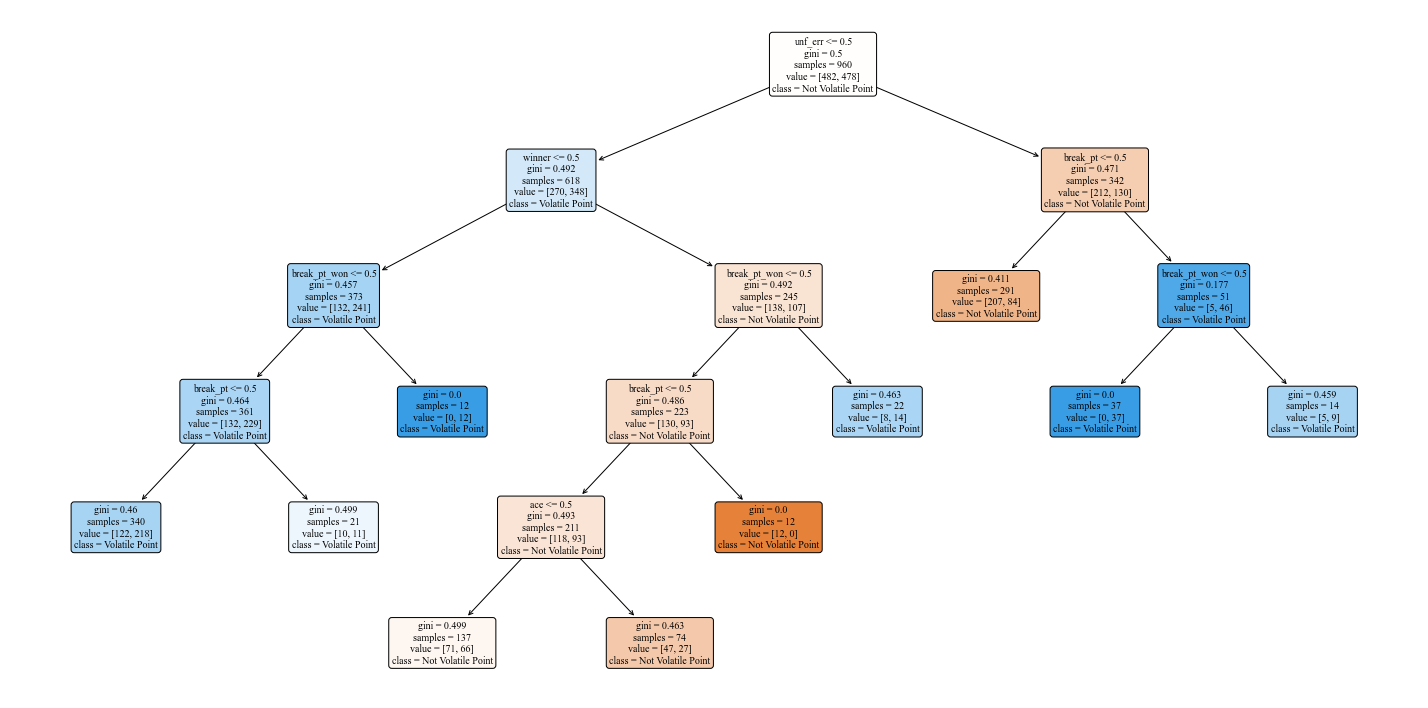

In [1034]:
# 可视化决策树
from sklearn.tree import plot_tree
plt.subplots(figsize=(20, 10))
tree_plot = plot_tree(clf, filled=True, feature_names=X.columns, class_names=['Not Volatile Point', 'Volatile Point'], rounded=True, fontsize=10)

plt.tight_layout()
plt.savefig('./决策树.png',dpi=500)
# 显示图形
plt.show()


## 测试决策树

In [1033]:
# 2018-wimbledon-1110
data = dataset_dict['2018-wimbledon-points']
data = data[data['match_id'] == '2018-wimbledon-1110'].reset_index(drop=True)
p1_factor, p2_factor = Factor(data)
p1_mmt, p2_mmt = Momentum(p1_factor, p2_factor)
# 定义阈值
b = 0.5
# 转换为 Pandas 的 Series 对象
p1_series = pd.Series(p1_mmt)
p2_series = pd.Series(p2_mmt)
# 计算波动点
momentum_points = (p1_series - p2_series).abs() < b
result = p1_series[momentum_points]
data['is_volatile_pt'] = 0
data.loc[result.index, 'is_volatile_pt'] = 1
# 测试集
vlt_pt_data = data[['p1_ace', 'p2_ace', 'p1_winner', 'p2_winner',
                             'p1_double_fault', 'p2_double_fault', 'p1_unf_err', 'p2_unf_err',
                             'p1_break_pt', 'p2_break_pt', 'p1_break_pt_won', 'p2_break_pt_won','is_volatile_pt']]

vlt_pt_data['ace'] = (vlt_pt_data['p1_ace'] | vlt_pt_data['p2_ace'])
vlt_pt_data['winner'] = (vlt_pt_data['p1_winner'] | vlt_pt_data['p2_winner'])
vlt_pt_data['double_fault'] = (vlt_pt_data['p1_double_fault'] | vlt_pt_data['p2_double_fault'])
vlt_pt_data['unf_err'] = (vlt_pt_data['p1_unf_err'] | vlt_pt_data['p2_unf_err'])
vlt_pt_data['break_pt'] = (vlt_pt_data['p1_break_pt'] | vlt_pt_data['p2_break_pt'])
vlt_pt_data['break_pt_won'] = (vlt_pt_data['p1_break_pt_won'] | vlt_pt_data['p2_break_pt_won'])

vlt_pt_data.drop(columns=['p1_ace', 'p2_ace', 'p1_winner', 'p2_winner',
                          'p1_double_fault', 'p2_double_fault', 'p1_unf_err', 'p2_unf_err',
                          'p1_break_pt', 'p2_break_pt', 'p1_break_pt_won', 'p2_break_pt_won'], inplace=True)

# 在测试集上进行预测
X = total_vltp_data[['ace','winner','double_fault','unf_err','break_pt','break_pt_won']]
y = total_vltp_data['is_volatile_pt']
y_pred = clf.predict(X)

# 评估模型性能
accuracy = metrics.accuracy_score(y, y_pred)
print("Accuracy:", accuracy)
df = pd.DataFrame({'y':y,'y_pred':y_pred})
print(((df['y'] == 1) & (df['y_pred'] == 1)).sum()/(df['y'] == 1).sum())

Accuracy: 0.6716666666666666
0.6366666666666667


## 平滑势头曲线（小波分析）

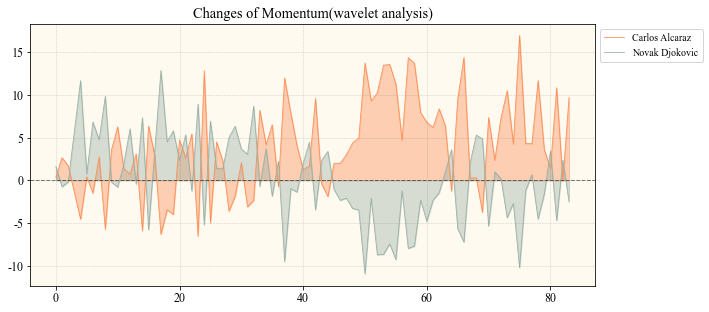

In [702]:
# 定义小波分析函数
def wavelet_analysis(data):
    # 使用小波变换
    coeffs = pywt.wavedec(data, 'haar', level=2)
    # 提取逼近系数和细节系数
    approx = coeffs[0][:len(data)] # 确保长度匹配
    details = [coeff[:len(data)] for coeff in coeffs[1:]] # 确保长度匹配
    return approx, details

# 对每个商品的小时销售数据进行粗略小波分析
approx1, details1 = wavelet_analysis(p1_mmt)
approx2, details2 = wavelet_analysis(p2_mmt)
fig, ax = plt.subplots(figsize=(10, 4.5))
plt.title('Changes of Momentum(wavelet analysis)')
ax.plot(approx1,label='Carlos Alcaraz',color='#FC8E56', lw = 0.8)
ax.plot(approx2,label='Novak Djokovic',color='#99B0A7', lw = 0.8)
# 在折线图下方填充颜色
ax.fill_between(range(len(approx1)), approx1, color='#FC8E56', interpolate=True, alpha=0.4)
ax.fill_between(range(len(approx2)), approx2, color='#99B0A7', interpolate=True, alpha=0.4)
# 添加 y=0 的参考线
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha = 0.5)
plt.legend(bbox_to_anchor=(1.2, 1),prop={'size': 10})
plt.grid(ls = "--", lw = 0.5, color = "#4E616C", alpha=0.3)
plt.gca().set_facecolor('#FFFAF0')

plt.tight_layout()
plt.savefig('./势头变化（小波变换）.png',dpi=500)
plt.show()

In [647]:
mmt = []
for i in range(len(p1_mmt)):
    if(p1_mmt[i] > p2_mmt[i]):
        mmt.append(1)
    else:
        mmt.append(2)
pt_victor = problem_data[problem_data['match_id'] == '2023-wimbledon-1701']['point_victor'].values
df = pd.DataFrame({'mmt':mmt,
                  'pt_vt':pt_victor})

df['pt_vt'] = df['pt_vt'].shift(4, fill_value=0)
df = df.drop(0).reset_index(drop = True)
df = df.drop(0).reset_index(drop = True)
df = df.drop(0).reset_index(drop = True)
df = df.drop(0).reset_index(drop = True)

# 除去势头相似的点
# rate_list = []
# for i in range(len(mmt)):
#     if p1_mmt[i] > p2_mmt[i] :
#         if p2_mmt[i] != 0:
#             rate = (p1_mmt[i] - p2_mmt[i]) / p2_mmt[i]
#         else:
#             rate = 1
#     else:
#         if p1_mmt[i] != 0:
#             rate = (p2_mmt[i] - p1_mmt[i]) / p1_mmt[i]
#         else:
#             rate = 1
#     rate_list.append(rate)

# for index, row in df.iterrows():
#     if rate_list[index] < 0.1:
#         df = df.drop(index)
# df = df.reset_index(drop=True)
print(len(df))
observed_table = pd.crosstab(df['mmt'], df['pt_vt'])
# 进行卡方检验
chi2, p, _, _ = chi2_contingency(observed_table)

# 输出卡方统计量和 p-value
print(f"Chi2 Statistic: {chi2}")
print(f"P-value: {p}")

# 根据 p-value 判断是否拒绝原假设
alpha = 0.05
if p < alpha:
    print("拒绝原假设，说明两列数据存在关联性")
else:
    print("接受原假设，说明两列数据不存在关联性")
    
# 匹配度
df['Match'] = df['mmt'] == df['pt_vt']

match_rate = df['Match'].mean()

print(f"匹配率: {match_rate * 100:.2f}%")

330
Chi2 Statistic: 94.66971800938677
P-value: 2.249542740265575e-22
拒绝原假设，说明两列数据存在关联性
匹配率: 76.36%


## 比赛流程可视化

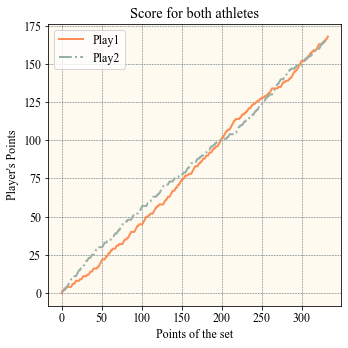

In [703]:
data = problem_data[problem_data['match_id'] == '2023-wimbledon-1701'].reset_index(drop=True)
# 比赛总得分
plt.figure(figsize=(5, 5))
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
p1_point = data['p1_points_won']
p2_point = data['p2_points_won']
plt.plot(p1_point, linestyle='-', linewidth=2, color = '#FC8E56',label = 'Play1')
plt.plot(p2_point, linestyle='-.', linewidth=2, color = '#99B0A7', label = 'Play2')
plt.xlabel("Points of the set")
plt.ylabel("Player's Points")
plt.title("Score for both athletes")


plt.legend()
plt.tight_layout()
plt.savefig('./运动员比分.png',dpi=500)
plt.show()

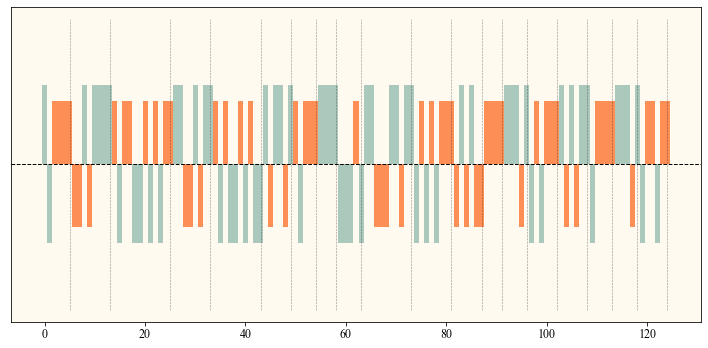

In [761]:
data = problem_data[problem_data['match_id'] == '2023-wimbledon-1701'].reset_index(drop=True)
# 创建一个图形对象
fig, ax = plt.subplots(figsize=(10, 5))
# plt.grid(ls = "--", lw = 0.5, color = "#4E616C", alpha=0.2)
plt.gca().set_facecolor('#FFFAF0')
# 获取数据
data = data[data['set_no'].isin([4,5])].reset_index(drop=True)
game_index = data[data['game_victor'] != 0].index
bp1_index = data[data['p1_break_pt'] == 1].index
bp2_index = data[data['p2_break_pt'] == 1].index
server = data['server']
p1_point = data['p1_points_won']
p2_point = data['p2_points_won']
p1_won = []
p2_won = []
p1_won.append(0)
p2_won.append(1)
for i in range(1,len(p1_point)):
    point = p1_point[i] - p1_point[i-1]
    if point == 1:
        if server[i] == 1:
            p1_won.append(0.8)
        else:
            p1_won.append(-0.8)
    else:
        p1_won.append(point)
    
for i in range(1,len(p2_point)):
    point = p2_point[i] - p2_point[i-1]
    if point == 1:
        if server[i] == 2:
            p2_won.append(1)
        else:
            p2_won.append(-1)
    else:
        p2_won.append(point)
        
# 绘制直方图
bar_width = 1  # 调整柱状图的宽度
bar_positions = np.arange(len(p1_won))

plt.bar(bar_positions, p1_won, width=bar_width, color='#FC8E56', label='Carlos Alcaraz')
plt.bar(bar_positions, p2_won, width=bar_width, color='#ABC8BC', label='Novak Djokovic')
# 添加 y=0 的参考线
plt.axhline(0, color='black', linestyle='--', linewidth=1)
# 在符合条件的行上画竖虚线
plt.vlines(game_index, ymin=-1.85, ymax=1.85, colors='black', linestyles='dashed', alpha = 0.4, lw = 0.6)
# 设置 x 轴和 y 轴标签
# plt.xlabel('Points of the set')
# plt.ylabel('Get Points at receiving/serving game')
plt.ylim(-2, 2)
plt.yticks([])
# # 在关键赛点位置画垂直线
# plt.vlines(bp1_index, ymin=-2, ymax=2, colors='blue', linestyles='-', lw = 0.6)
# plt.vlines(bp2_index, ymin=-2, ymax=2, colors='red', linestyles='-', lw = 0.6)
# 添加图例
# plt.legend(bbox_to_anchor=(1, 1.22),prop={'size': 12})

# 显示图形
plt.tight_layout()
plt.savefig('./比赛流程2.png', dpi=500)
plt.show()

## 球员评价指标计算

In [1045]:
data = problem_data[problem_data['match_id'] == '2023-wimbledon-1701'].reset_index(drop=True)
# 八个指标的数组
p1_ace_ratio = []
p2_ace_ratio = []
p1_df_ratio = []
p2_df_ratio = []
p1_s = []
p2_s = []
p1_fs = []
p2_fs = []
p1_ss = []
p2_ss = []
p1_bk_ratio = []
p2_bk_ratio = []
p1_fb_ratio = []
p2_fb_ratio = []
p1_unf_err_ratio = []
p2_unf_err_ratio = []

for index, row in data.iterrows():
    tmp = data.head(index + 1)
    # 运动员发球次数
    p1_server = len(tmp[tmp['server'] == 1])
    p2_server = len(tmp[tmp['server'] == 2])
    
    if p1_server == 0 and p2_server != 0:
        p1_ace_ratio.append(0)
        p1_df_ratio.append(0)
        p1_s.append(0)
        p1_fs.append(0)
        p1_ss.append(0)
        p2_ace_ratio.append(len(tmp[tmp['p2_ace'] == 1]) / p2_server)
        p2_df_ratio.append(len(tmp[tmp['p2_double_fault'] == 1]) / p2_server)
        p2_s.append(len(tmp[(tmp['server'] == 2) & (tmp['serve_no'] == 1)]) / p2_server)
        p2_fs.append(len(tmp[(tmp['server'] == 2) & (tmp['serve_no'] == 1) & (tmp['point_victor'] == 2)]) / p2_server)
        p2_ss.append(len(tmp[(tmp['server'] == 2) & (tmp['serve_no'] == 2)]) / p2_server)
    elif p2_server == 0 and p1_server != 0:
        p2_ace_ratio.append(0)
        p2_df_ratio.append(0)
        p2_s.append(0)
        p2_fs.append(0)
        p2_ss.append(0)
        p1_ace_ratio.append(len(tmp[tmp['p1_ace'] == 1]) / p1_server)
        p1_df_ratio.append(len(tmp[tmp['p1_double_fault'] == 1]) / p1_server)
        p1_s.append(len(tmp[(tmp['server'] == 1) & (tmp['serve_no'] == 1)]) / p1_server)
        p1_fs.append(len(tmp[(tmp['server'] == 1) & (tmp['serve_no'] == 1) & (tmp['point_victor'] == 1)]) / p1_server)
        p1_ss.append(len(tmp[(tmp['server'] == 1) & (tmp['serve_no'] == 2)]) / p1_server)
    else:
        # ace率（越大越好）
        p1_ace_ratio.append(len(tmp[tmp['p1_ace'] == 1]) / p1_server)
        p2_ace_ratio.append(len(tmp[tmp['p2_ace'] == 1]) / p2_server)
        # 双误率（越小越好）
        p1_df_ratio.append(len(tmp[tmp['p1_double_fault'] == 1]) / p1_server)
        p2_df_ratio.append(len(tmp[tmp['p2_double_fault'] == 1]) / p2_server)
        # 一发成功率（越大越好）
        p1_s.append(len(tmp[(tmp['server'] == 1) & (tmp['serve_no'] == 1)]) / p1_server)
        p2_s.append(len(tmp[(tmp['server'] == 2) & (tmp['serve_no'] == 1)]) / p2_server)
        # 一发得分率（越大越好）
        p1_fs.append(len(tmp[(tmp['server'] == 1) & (tmp['serve_no'] == 1) & (tmp['point_victor'] == 1)]) / p1_server)
        p2_fs.append(len(tmp[(tmp['server'] == 2) & (tmp['serve_no'] == 1) & (tmp['point_victor'] == 2)]) / p2_server)
        # 二发得分率（越大越好）
        p1_ss.append(len(tmp[(tmp['server'] == 1) & (tmp['serve_no'] == 2) & (tmp['point_victor'] == 1)]) / p1_server)
        p2_ss.append(len(tmp[(tmp['server'] == 2) & (tmp['serve_no'] == 2) & (tmp['point_victor'] == 2)]) / p2_server)
        
    if(len(tmp[tmp['p1_break_pt'] == 1]) == 0) and (len(tmp[tmp['p2_break_pt'] == 1]) == 0):
        p1_bk_ratio.append(0)
        p2_bk_ratio.append(0)
    elif(len(tmp[tmp['p1_break_pt'] == 1]) == 0) and (len(tmp[tmp['p2_break_pt'] == 1]) != 0):
        p1_bk_ratio.append(0)
        p2_bk_ratio.append(len(tmp[tmp['p2_break_pt_won'] == 1]) / len(tmp[tmp['p2_break_pt'] == 1]))
    elif(len(tmp[tmp['p2_break_pt'] == 1]) == 0) and (len(tmp[tmp['p1_break_pt'] == 1]) != 0):
        p2_bk_ratio.append(0)
        p1_bk_ratio.append(len(tmp[tmp['p1_break_pt_won'] == 1]) / len(tmp[tmp['p1_break_pt'] == 1]))
    else:
        # 破发成功率（越大越好）
        p1_bk_ratio.append(len(tmp[tmp['p1_break_pt_won'] == 1]) / len(tmp[tmp['p1_break_pt'] == 1]))
        p2_bk_ratio.append(len(tmp[tmp['p2_break_pt_won'] == 1]) / len(tmp[tmp['p2_break_pt'] == 1]))
        
    if(len(tmp[(tmp['winner_shot_type'] == 'B') & (tmp['p1_winner'] == 1)]) == 0) and (len(tmp[(tmp['winner_shot_type'] == 'B') & (tmp['p2_winner'] == 1)]) == 0):
        p1_fb_ratio.append(0)
        p2_fb_ratio.append(0)
    elif(len(tmp[(tmp['winner_shot_type'] == 'B') & (tmp['p1_winner'] == 1)]) == 0) and (len(tmp[(tmp['winner_shot_type'] == 'B') & (tmp['p2_winner'] == 1)]) != 0):
        p1_fb_ratio.append(0)
        p2_fb_ratio.append(len(tmp[(tmp['winner_shot_type'] == 'F') & (tmp['p2_winner'] == 1)]) / len(tmp[(tmp['winner_shot_type'] == 'B') & (tmp['p2_winner'] == 1)]))
    elif(len(tmp[(tmp['winner_shot_type'] == 'B') & (tmp['p2_winner'] == 1)]) == 0) and (len(tmp[(tmp['winner_shot_type'] == 'B') & (tmp['p1_winner'] == 1)]) != 0):
        p1_fb_ratio.append(len(tmp[(tmp['winner_shot_type'] == 'F') & (tmp['p1_winner'] == 1)]) / len(tmp[(tmp['winner_shot_type'] == 'B') & (tmp['p1_winner'] == 1)]))
        p2_fb_ratio.append(0)
    else:
        # 正反手杀球比例（越靠近1越好）
        p1_fb_ratio.append(len(tmp[(tmp['winner_shot_type'] == 'F') & (tmp['p1_winner'] == 1)]) / len(tmp[(tmp['winner_shot_type'] == 'B') & (tmp['p1_winner'] == 1)]))
        p2_fb_ratio.append(len(tmp[(tmp['winner_shot_type'] == 'F') & (tmp['p2_winner'] == 1)]) / len(tmp[(tmp['winner_shot_type'] == 'B') & (tmp['p2_winner'] == 1)]))
    
    # 非压迫性失误率（越小越好）
    p1_unf_err_ratio.append(len(tmp[tmp['p1_unf_err'] == 1]) / sum(tmp['rally_count']))
    p2_unf_err_ratio.append(len(tmp[tmp['p2_unf_err'] == 1]) / sum(tmp['rally_count']))

In [1046]:
score_dict1 = {
    'ace_ratio': p1_ace_ratio,
    'df_ratio': p1_df_ratio,
    's': p1_s,
    'fs': p1_fs,
    'ss': p1_ss,
    'bk_ratio': p1_bk_ratio,
    'fb_ratio': p1_fb_ratio,
    'unf_err_ratio': p1_unf_err_ratio,
}

score_dict2 = {
    'ace_ratio': p2_ace_ratio,
    'df_ratio': p2_df_ratio,
    's': p2_s,
    'fs': p2_fs,
    'ss': p2_ss,
    'bk_ratio': p2_bk_ratio,
    'fb_ratio': p2_fb_ratio,
    'unf_err_ratio': p2_unf_err_ratio,
}
# 创建 DataFrame
score_df1 = pd.DataFrame(score_dict1)
score_df2 = pd.DataFrame(score_dict2)
score_df1.head()

,ace_ratio,df_ratio,s,fs,ss,bk_ratio,fb_ratio,unf_err_ratio
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 保存各指标数据文件

In [1047]:
score_df1.to_csv('socre_df1.csv', index=False)
score_df2.to_csv('socre_df2.csv', index=False)

## 熵权TOPSIS计算指标权重

In [349]:
df = pd.read_csv('./df.csv')
# 原始数据正向化
# 极小型指标 --> 极大型指标
df['double_fault'] = 1 / df['double_fault']
df['unf_err'] = 1 / df['unf_err']
# 中间型指标 --> 极大型指标
M = max(abs(df['f'] - 1))
df['f'] = 1 - abs(df['f'] - 1)/M

In [350]:
# 矩阵标准化
df = (df - df.mean()) / df.std()

In [351]:
# 矩阵归一化
df = (df - df.min()) / (df.max() - df.min())

In [354]:
# 计算各指标权重
z = df
# 概率矩阵
z = z / z.sum()
# 计算熵值
e = (-z * np.log(z)).sum()/len(z)
d = 1 - e
w = d/d.sum()
w['ace'] = 0.22
w['double_fault'] = 0.23
w['s'] = 0.10
w['fs'] = 0.12
w['ss'] = 0.05
w['b'] = 0.15
w['f'] = 0.07
w['unf_err'] = 0.06

1.0

In [399]:
# 原始数据正向化
# 极小型指标 --> 极大型指标
score_df1['df_ratio'] = 1 / score_df1['df_ratio']
score_df2['df_ratio'] = 1 / score_df2['df_ratio']
score_df1['unf_err_ratio'] = 1 / score_df1['unf_err_ratio']
score_df2['unf_err_ratio'] = 1 / score_df2['unf_err_ratio']
# 中间型指标 --> 极大型指标
M = max(abs(score_df1['fb_ratio'] - 1))
score_df1['fb_ratio'] = 1 - abs(score_df1['fb_ratio'] - 1)/M
M = max(abs(score_df2['fb_ratio'] - 1))
score_df2['fb_ratio'] = 1 - abs(score_df2['fb_ratio'] - 1)/M
# 矩阵标准化
score_df1 = (score_df1 - score_df1.mean()) / score_df1.std()
score_df2 = (score_df2 - score_df2.mean()) / score_df2.std()
# 矩阵归一化
score_df1 = (score_df1 - score_df1.min()) / (score_df1.max() - score_df1.min())
score_df2 = (score_df2 - score_df2.min()) / (score_df2.max() - score_df2.min())
# 计算得分并归一化
z1_max = score_df1.max()
z2_max = score_df2.max()
z1_min = score_df1.min()
z2_min = score_df2.min()
# 计算每个评价对象与最大值的距离,最小值的距离
d1_max = np.sqrt(((w * (z1_max - score_df1)**2).sum(axis=1)))
d1_min = np.sqrt(((w * (z1_min - score_df1)**2).sum(axis=1)))

d2_max = np.sqrt(((w * (z2_max - score_df2)**2).sum(axis=1)))
d2_min = np.sqrt(((w * (z2_min - score_df2)**2).sum(axis=1)))

S1 = (d1_min / (d1_max + d1_min))*100
S2 = (d2_min / (d2_max + d2_min))*100

S1.to_csv('score1.csv', index=False)
S2.to_csv('score2.csv', index=False)

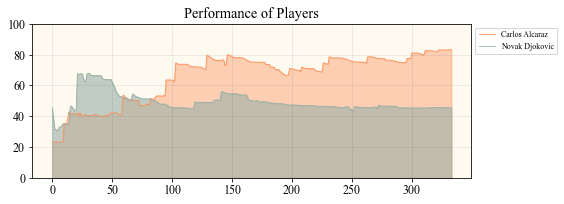

In [1035]:
fig, ax = plt.subplots(figsize=(8, 3))
plt.grid(ls = "--", lw = 0.5, color = "#4E616C", alpha = 0.3)
plt.gca().set_facecolor('#FFFAF0')
plt.plot(S1,label='Carlos Alcaraz',color = '#FC8E56', lw = 0.8)
plt.plot(S2,label='Novak Djokovic',color = '#99B0A7', lw = 0.8)
# 在折线图下方填充颜色
ax.fill_between(range(len(S1)), S1, color='#FC8E56', interpolate=True, alpha=0.4)
ax.fill_between(range(len(S2)), S2, color='#99B0A7', interpolate=True, alpha=0.6)

plt.ylim(0,100)

plt.title('Performance of Players')
plt.legend(bbox_to_anchor=(1, 1),prop={'size': 8})
plt.tight_layout()
plt.savefig('./运动员的表现.png', dpi=500)
plt.show()

## 球员综合评价

In [1066]:
from sklearn.preprocessing import MinMaxScaler
score1 = pd.read_csv('./socre_df1.csv')
score2 = pd.read_csv('./socre_df2.csv')

# 初始化MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 100))
# 对每一列进行MinMax缩放
score1 = pd.DataFrame(scaler.fit_transform(score1), columns=score1.columns)
mean1 = score1.mean()
score2 = pd.DataFrame(scaler.fit_transform(score2), columns=score2.columns)
mean2 = score2.mean()
print(mean1.values)
print(mean2.values)

[49.51503402 46.35327316 64.49229404 84.22572653 71.77616253 63.83261977
 29.61157721 51.78425127]
[31.8018441  51.24822049 29.26901355 27.87638844 37.69193301 80.57355569
 35.19739093 25.0191849 ]


In [1067]:
data = pd.DataFrame({'metrics':['ACE', 'Double Fault', 'Successful Serve', 'Score at First Serve', 'Score at Secnond Serve', 'Score at Break Point', 'Forehand and Backhand Kill Ratio', 'Unforced Error'],
                    'data':[49.51503402,46.35327316,64.49229404,84.22572653,71.77616253,63.83261977,29.61157721,51.78425127]})
data.to_csv('mean1.csv', index=False)
data = pd.DataFrame({'metrics':['ACE', 'Double Fault', 'Successful Serve', 'Score at First Serve', 'Score at Secnond Serve', 'Score at Break Point', 'Forehand and Backhand Kill Ratio', 'Unforced Error'],
                    'data':[31.8018441,51.24822049,29.26901355,27.87638844,37.69193301,80.57355569,35.19739093,25.0191849]})
data.to_csv('mean2.csv', index=False)


## 推广到其他比赛（17年法网男单，20年美网男双，23年温网混双）

In [1117]:
f = pd.read_csv('./other_games/2017-frenchopen-points.csv')
u = pd.read_csv('./other_games/2020-usopen-points-doubles.csv')
w = pd.read_csv('./other_games/2023-wimbledon-points-mixed.csv')

In [1118]:
# 去掉空白的列
f = f.dropna(axis=1, how='all')
u = u.dropna(axis=1, how='all')
w = w.dropna(axis=1, how='all')
print(f.columns)
print(len(f.columns))
print(u.columns)
print(len(u.columns))
print(w.columns)
print(len(w.columns))

Index(['match_id', 'ElapsedTime', 'SetNo', 'P1GamesWon', 'P2GamesWon',
       'SetWinner', 'GameNo', 'GameWinner', 'PointNumber', 'PointWinner',
       'PointServer', 'Speed_KMH', 'P1Score', 'P2Score', 'P1PointsWon',
       'P2PointsWon', 'P1Ace', 'P2Ace', 'P1Winner', 'P2Winner',
       'P1DoubleFault', 'P2DoubleFault', 'P1UnfErr', 'P2UnfErr', 'P1NetPoint',
       'P2NetPoint', 'P1NetPointWon', 'P2NetPointWon', 'P1BreakPoint',
       'P2BreakPoint', 'P1BreakPointWon', 'P2BreakPointWon', 'History',
       'Speed_MPH', 'P1BreakPointMissed', 'P2BreakPointMissed',
       'ServeIndicator', 'ServeNumber', 'WinnerType', 'WinnerShotType',
       'P1DistanceRun', 'P2DistanceRun', 'RallyCount', 'ServeWidth',
       'ServeDepth', 'ReturnDepth'],
      dtype='object')
46
Index(['match_id', 'ElapsedTime', 'SetNo', 'P1GamesWon', 'P2GamesWon',
       'SetWinner', 'GameNo', 'GameWinner', 'PointNumber', 'PointWinner',
       'PointServer', 'Speed_KMH', 'P1Score', 'P2Score', 'P1Momentum',
       'P2Mome

In [1119]:
# 找出12个df共同的列
columns_sets = [set(f.columns),set(u.columns),set(w.columns)]
columns_inter = reduce(set.intersection, columns_sets)
# 打印结果
print("列名交集:", columns_inter)
print("数量:",len(columns_inter))
# 只保留相同的列
f = f.loc[:, columns_inter]
u = u.loc[:, columns_inter]
w = w.loc[:, columns_inter]
print(f.columns)

列名交集: {'P1Score', 'P1Winner', 'P2GamesWon', 'RallyCount', 'GameWinner', 'P2BreakPointMissed', 'ServeIndicator', 'ServeNumber', 'SetNo', 'ElapsedTime', 'P2Winner', 'P1NetPointWon', 'P2BreakPoint', 'P1PointsWon', 'P2NetPoint', 'P1DistanceRun', 'WinnerShotType', 'P1BreakPointMissed', 'SetWinner', 'P1Ace', 'PointWinner', 'PointServer', 'P2NetPointWon', 'P2Score', 'P1GamesWon', 'P1DoubleFault', 'P2UnfErr', 'P1BreakPoint', 'match_id', 'P1UnfErr', 'P2BreakPointWon', 'GameNo', 'P2DistanceRun', 'WinnerType', 'Speed_MPH', 'History', 'P1NetPoint', 'Speed_KMH', 'P2PointsWon', 'PointNumber', 'P2Ace', 'P2DoubleFault', 'P1BreakPointWon'}
数量: 43
Index(['P1Score', 'P1Winner', 'P2GamesWon', 'RallyCount', 'GameWinner',
       'P2BreakPointMissed', 'ServeIndicator', 'ServeNumber', 'SetNo',
       'ElapsedTime', 'P2Winner', 'P1NetPointWon', 'P2BreakPoint',
       'P1PointsWon', 'P2NetPoint', 'P1DistanceRun', 'WinnerShotType',
       'P1BreakPointMissed', 'SetWinner', 'P1Ace', 'PointWinner',
       'PointSe

In [1120]:
drop_columns = ['Speed_KMH', 'History', 'WinnerType', 'ServeIndicator']
new_columns = ['p1_score', 'p1_winner', 'p2_games', 'rally_count', 'game_victor',
               'p2_break_pt_missed', 'serve_no', 'set_no',
               'elapsed_time',  'p2_winner', 'p1_net_pt_won',
               'p2_break_pt', 'p1_points_won', 'p2_net_pt', 'p1_distance_run',
               'winner_shot_type', 'p1_break_pt_missed', 'set_victor', 'p1_ace',
               'point_victor', 'server', 'p2_net_pt_won', 'p2_score', 'p1_games',
               'p1_double_fault', 'p2_unf_err', 'p1_break_pt', 'match_id',
               'p1_unf_err', 'p2_break_pt_won', 'game_no', 'p2_distance_run',
               'Speed_MPH',  'p1_net_pt', 'p2_points_won',
               'point_no', 'p2_ace', 'p2_double_fault', 'p1_break_pt_won']
f = f.drop(columns=drop_columns)
f.columns = new_columns
u = u.drop(columns=drop_columns)
u.columns = new_columns
w = w.drop(columns=drop_columns)
w.columns = new_columns
print(f.columns)
print(len(f.columns))

Index(['p1_score', 'p1_winner', 'p2_games', 'rally_count', 'game_victor',
       'p2_break_pt_missed', 'serve_no', 'set_no', 'elapsed_time', 'p2_winner',
       'p1_net_pt_won', 'p2_break_pt', 'p1_points_won', 'p2_net_pt',
       'p1_distance_run', 'winner_shot_type', 'p1_break_pt_missed',
       'set_victor', 'p1_ace', 'point_victor', 'server', 'p2_net_pt_won',
       'p2_score', 'p1_games', 'p1_double_fault', 'p2_unf_err', 'p1_break_pt',
       'match_id', 'p1_unf_err', 'p2_break_pt_won', 'game_no',
       'p2_distance_run', 'Speed_MPH', 'p1_net_pt', 'p2_points_won',
       'point_no', 'p2_ace', 'p2_double_fault', 'p1_break_pt_won'],
      dtype='object')
39


In [1121]:
new_columns = ['match_id', 'elapsed_time', 'set_no', 'game_no', 'point_no', 
               'p1_games', 'p2_games', 'p1_score', 'p2_score', 'server',
               'serve_no', 'point_victor', 'p1_points_won', 'p2_points_won',
               'game_victor', 'set_victor', 'p1_ace', 'p2_ace', 'p1_winner',
               'p2_winner', 'winner_shot_type', 'p1_double_fault', 'p2_double_fault',
               'p1_unf_err', 'p2_unf_err', 'p1_net_pt', 'p2_net_pt', 'p1_net_pt_won',
               'p2_net_pt_won', 'p1_break_pt', 'p2_break_pt', 'p1_break_pt_won',
               'p2_break_pt_won', 'p1_break_pt_missed', 'p2_break_pt_missed',
               'p1_distance_run', 'p2_distance_run', 'rally_count', 'speed_mph']
print(len(new_columns))

39


In [1123]:
f = f.reindex(columns=new_columns)
u = u.reindex(columns=new_columns)
w = w.reindex(columns=new_columns)
print(f.columns)

Index(['match_id', 'elapsed_time', 'set_no', 'game_no', 'point_no', 'p1_games',
       'p2_games', 'p1_score', 'p2_score', 'server', 'serve_no',
       'point_victor', 'p1_points_won', 'p2_points_won', 'game_victor',
       'set_victor', 'p1_ace', 'p2_ace', 'p1_winner', 'p2_winner',
       'winner_shot_type', 'p1_double_fault', 'p2_double_fault', 'p1_unf_err',
       'p2_unf_err', 'p1_net_pt', 'p2_net_pt', 'p1_net_pt_won',
       'p2_net_pt_won', 'p1_break_pt', 'p2_break_pt', 'p1_break_pt_won',
       'p2_break_pt_won', 'p1_break_pt_missed', 'p2_break_pt_missed',
       'p1_distance_run', 'p2_distance_run', 'rally_count', 'speed_mph'],
      dtype='object')


In [1124]:
f

,match_id,elapsed_time,set_no,game_no,point_no,p1_games,p2_games,p1_score,p2_score,server,...,p1_break_pt,p2_break_pt,p1_break_pt_won,p2_break_pt_won,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph
0,2017-frenchopen-1101,0:00:00,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0.000,0.000,0,NaN
1,2017-frenchopen-1101,0:00:00,1,1,1,0,0,0,15,1,...,0,0,0,0,0,0,5.363,5.417,2,NaN
2,2017-frenchopen-1101,0:00:44,1,1,2,0,0,0,30,1,...,0,0,0,0,0,0,22.752,18.474,8,NaN
3,2017-frenchopen-1101,0:01:27,1,1,3,0,0,0,40,1,...,0,0,0,0,0,0,29.321,22.901,10,NaN
4,2017-frenchopen-1101,0:02:25,1,1,4,0,0,15,40,1,...,0,1,0,0,0,1,8.945,9.605,3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43117,2017-frenchopen-2701,1:58:18,3,9,192,5,3,15,15,2,...,0,0,0,0,0,0,3.798,3.657,2,NaN
43118,2017-frenchopen-2701,1:58:34,3,9,193,5,3,30,15,2,...,0,0,0,0,0,0,2.884,3.763,2,NaN
43119,2017-frenchopen-2701,1:58:52,3,9,194,5,3,30,30,2,...,0,0,0,0,0,0,2.648,3.993,1,NaN
43120,2017-frenchopen-2701,1:59:18,3,9,195,5,3,40,30,2,...,0,0,0,0,0,0,4.535,2.847,2,NaN


In [1125]:
f = f[~((f['point_no'] == '0X') | (f['point_no'] == '0Y'))]
u = u[~((u['point_no'] == '0X') | (u['point_no'] == '0Y'))]
w = w[~((f['point_no'] == '0X') | (w['point_no'] == '0Y'))]

In [1126]:
for data in [f,u,w]:
    mean = data[data['speed_mph'] != 0]['speed_mph'].mean()
    data['speed_mph'].fillna(mean, inplace=True)
    data['p1_score'].replace('AD', 50, inplace=True)
    data['p2_score'].replace('AD', 50, inplace=True)

In [1127]:
# 改正server列的异常值
# server = 1 or 2
server = f['server'][0]
for i in range(1,len(f)):
    f['server'][i] = server
    if(f['game_victor'][i] != 0) and i != (len(f) - 1):
        server = f['server'][i+1]